In [ ]:
# Install libraries
!pip install seaborn
!pip install ucimlrepo
!pip install imbalanced-learn
!pip install xgboost


In [ ]:
# Breast Cancer Classification: Multi-Model Comparison
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    classification_report
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer

# Additional Libraries
from ucimlrepo import fetch_ucirepo
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb

In [ ]:
def load_and_preprocess_data():
    """
    Load Breast Cancer Wisconsin Diagnostic dataset and preprocess

    Returns:
    - X (features)
    - y (target)
    """
    # Fetch dataset
    breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

    # Extract Features and Targets
    X = breast_cancer_wisconsin_diagnostic.data.features
    y = breast_cancer_wisconsin_diagnostic.data.targets

    # Drop unnecessary columns
    X = X.drop(columns=['ID'], errors='ignore')

    # Extract the 'Diagnosis' column
    y = y['Diagnosis']

    # Map target labels
    y = y.map({'B': 0, 'M': 1})

    # Encode Labels to Binary
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y.ravel())

    return X, y

In [ ]:
def scale_data(X):
    """
    Scale features using StandardScaler

    Args:
    - X (features)

    Returns:
    - Scaled features
    """
    scaler = StandardScaler()
    return scaler.fit_transform(X)

In [ ]:
def train_svm_model(X_train, X_test, y_train, y_test):
    """
    Train and evaluate Support Vector Machine Model
    """
    print("\n--- Support Vector Machine (SVM) Results ---")
    svm_model = SVC(kernel='linear', C=1.0, random_state=42)
    svm_model.fit(X_train, y_train)

    y_pred = svm_model.predict(X_test)

    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

    return svm_model

In [ ]:
def train_knn_model(X_train, X_test, y_train, y_test):
    """
    Train and evaluate K-Nearest Neighbors Model
    """
    print("\n--- K-Nearest Neighbors (KNN) Results ---")
    k_range = range(1, 21)
    accuracies = []

    for k in k_range:
        knn_model = KNeighborsClassifier(n_neighbors=k)
        knn_model.fit(X_train, y_train)
        accuracies.append(knn_model.score(X_test, y_test))

    best_k = k_range[accuracies.index(max(accuracies))]

    knn_model = KNeighborsClassifier(n_neighbors=best_k)
    knn_model.fit(X_train, y_train)
    y_pred = knn_model.predict(X_test)

    print(f"Best Number of Neighbors (k): {best_k}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

    return knn_model

In [ ]:
def train_logistic_regression_model(X_train, X_test, y_train, y_test):
    """
    Train and evaluate Logistic Regression Model
    """
    print("\n--- Logistic Regression Results ---")
    lr_model = LogisticRegression(random_state=0, max_iter=10000)
    lr_model.fit(X_train, y_train)

    y_pred = lr_model.predict(X_test)

    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

    return lr_model

In [ ]:
def train_neural_network_model(X_train, X_test, y_train, y_test):
    """
    Train and evaluate Neural Network Model with SMOTE
    """
    print("\n--- Neural Network Results ---")
    pipeline = ImbPipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('mlp', MLPClassifier(max_iter=1000, random_state=42))
    ])

    param_grid = {
        'mlp__hidden_layer_sizes': [(50,), (100,), (50, 50)],
        'mlp__activation': ['tanh', 'relu'],
        'mlp__solver': ['adam'],
        'mlp__alpha': [0.0001, 0.001],
        'mlp__learning_rate_init': [0.001, 0.01]
    }

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='f1', cv=cv, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]):.4f}")

    return best_model

In [ ]:
def train_xgboost_model(X_train, X_test, y_train, y_test):
    """
    Train and evaluate XGBoost Model
    """
    print("\n--- XGBoost Results ---")
    xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

    param_grid = {
        'n_estimators': [50, 100, 150],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }

    grid_search = GridSearchCV(estimator=xgb_clf, param_grid=param_grid, cv=5, scoring='accuracy', verbose=0, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

    return best_model

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrices(models, X_test, y_test):
    """
    Plot confusion matrices for all models.
    """
    for model_name, model in models.items():
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title(f'Confusion Matrix: {model_name}')
        plt.show()

def plot_metrics_comparison(metrics):
    """
    Plot comparison of different metrics across models.
    Args:
        metrics (dict): Dictionary with model names as keys and metrics as values.
    """
    metrics_df = pd.DataFrame(metrics).T
    metrics_df.plot(kind='bar', figsize=(10, 6))
    plt.title('Model Performance Comparison')
    plt.ylabel('Score')
    plt.xlabel('Models')
    plt.xticks(rotation=45)
    plt.legend(title='Metrics')
    plt.tight_layout()
    plt.show()

def plot_roc_curves(models, X_test, y_test):
    """
    Plot ROC curves for all models.
    """
    plt.figure(figsize=(10, 8))
    for model_name, model in models.items():
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        else:  # For models like SVM that don't have predict_proba
            y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc_score(y_test, y_score):.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title('ROC Curves')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()


In [ ]:
def main():
    # Set random seed for reproducibility
    np.random.seed(42)

    # Load and preprocess data
    X, y = load_and_preprocess_data()

    # Scale features
    X_scaled = scale_data(X)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

    # Train and evaluate models
    models = {
        'SVM': train_svm_model(X_train, X_test, y_train, y_test),
        'KNN': train_knn_model(X_train, X_test, y_train, y_test),
        'Logistic Regression': train_logistic_regression_model(X_train, X_test, y_train, y_test),
        'Neural Network': train_neural_network_model(X_train, X_test, y_train, y_test),
        'XGBoost': train_xgboost_model(X_train, X_test, y_train, y_test)

    }
    # Collect metrics for visualization
    metrics = {}
    for model_name, model in models.items():
        y_pred = model.predict(X_test)
        metrics[model_name] = {
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred)
        }

    # Visualization
    print("\nGenerating visualizations...")
    plot_metrics_comparison(metrics)  # Plot metrics bar chart
    plot_confusion_matrices(models, X_test, y_test)  # Plot confusion matrices
    plot_roc_curves(models, X_test, y_test)  # Plot ROC curves
    print("Visualizations complete.")




<ipython-input-4-f54237963bc5>:27: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y = label_encoder.fit_transform(y.ravel())



--- Support Vector Machine (SVM) Results ---
Accuracy: 0.9649
Precision: 1.0000
Recall: 0.9048
F1 Score: 0.9500

--- K-Nearest Neighbors (KNN) Results ---
Best Number of Neighbors (k): 5
Accuracy: 0.9561
Precision: 0.9744
Recall: 0.9048
F1 Score: 0.9383

--- Logistic Regression Results ---
Accuracy: 0.9649
Precision: 0.9750
Recall: 0.9286
F1 Score: 0.9512

--- Neural Network Results ---
Best Parameters: {'mlp__activation': 'relu', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (50,), 'mlp__learning_rate_init': 0.001, 'mlp__solver': 'adam'}
Accuracy: 0.9561
Precision: 0.9744
Recall: 0.9048
F1 Score: 0.9383
ROC AUC: 0.9934

--- XGBoost Results ---


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [22:54:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Accuracy: 0.9737
Precision: 1.0000
Recall: 0.9286
F1 Score: 0.9630
ROC AUC: 0.9927

Generating visualizations...


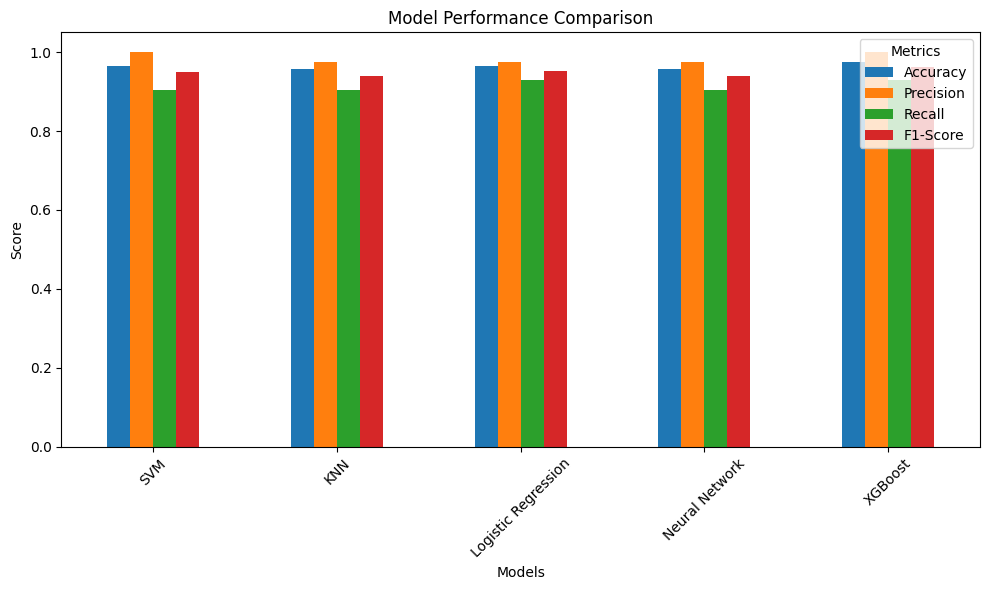

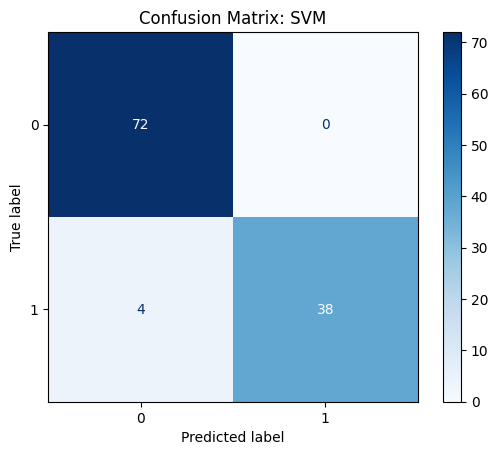

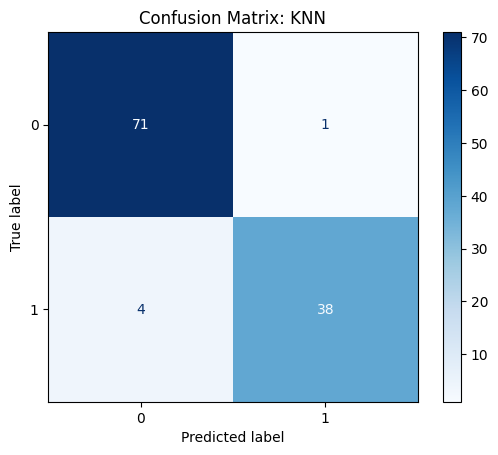

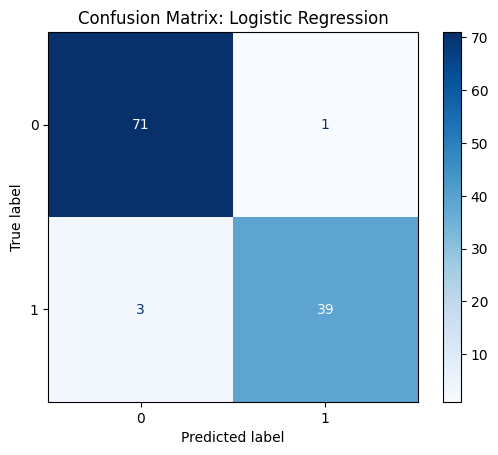

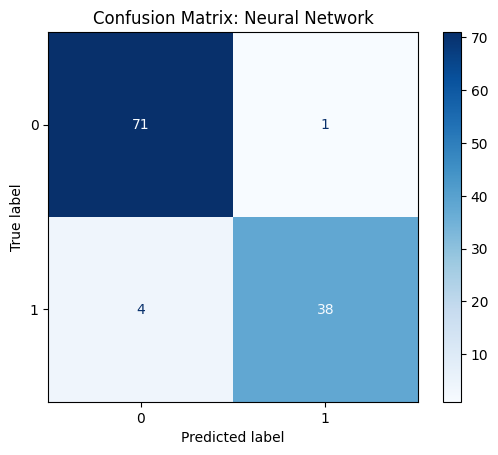

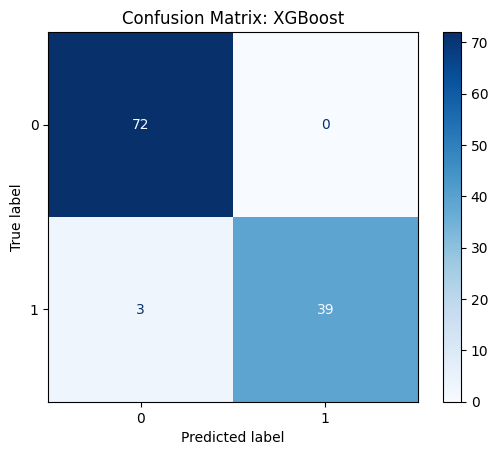

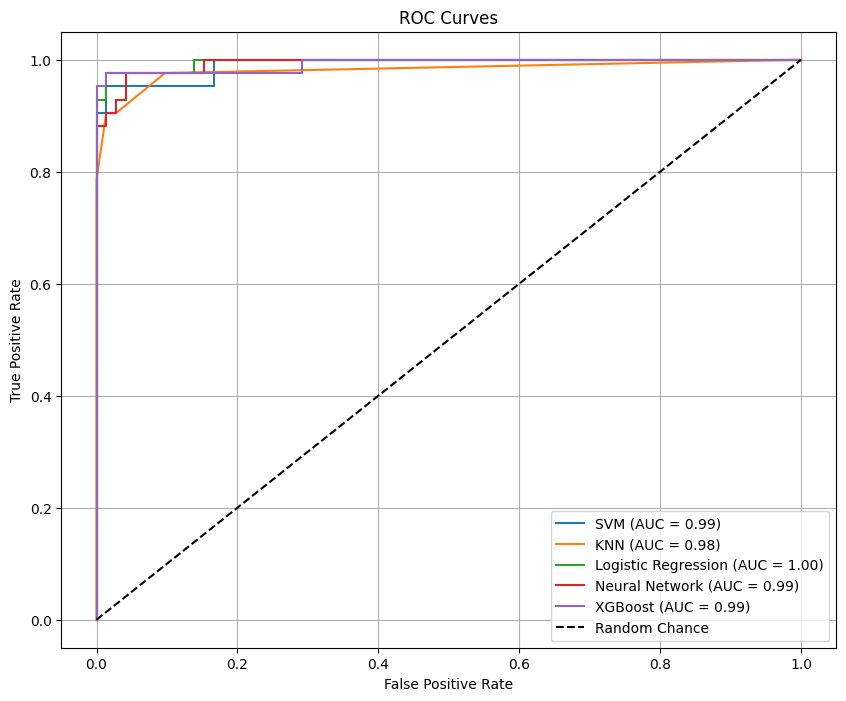

Visualizations complete.


In [ ]:
if __name__ == "__main__":
    main()


#Testing

In [ ]:
from google.colab import files

# Trigger the file upload dialog
uploaded = files.upload()

# Display the name of the uploaded file
image_path = next(iter(uploaded))  # Get the name of the uploaded image file
print(f"Uploaded file: {image_path}")


Saving applsci-12-03273-g001b.png to applsci-12-03273-g001b.png
Uploaded file: applsci-12-03273-g001b.png


In [ ]:
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops
from scipy.spatial import distance

def extract_features(image_path):
    # Read the image
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Thresholding to separate the object from background
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None

    # Assume the largest contour is our object of interest
    contour = max(contours, key=cv2.contourArea)

    # Calculate features
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    # Radius (approximated as half the major axis of an enclosing ellipse)
    (_, _), (major_axis, minor_axis), _ = cv2.fitEllipse(contour)
    radius = major_axis / 2

    # Compactness
    compactness = (perimeter ** 2) / (4 * np.pi * area)

    # Smoothness (inverse of compactness)
    smoothness = 1 / compactness

    # Concavity (ratio of area of concave regions to total area)
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    concavity = (hull_area - area) / hull_area

    # Symmetry (ratio of overlapping area when flipped)
    moments = cv2.moments(contour)
    cx = int(moments['m10'] / moments['m00'])
    cy = int(moments['m01'] / moments['m00'])
    flipped = cv2.flip(thresh, 1)
    overlap = cv2.bitwise_and(thresh, flipped)
    symmetry = np.sum(overlap) / np.sum(thresh)

    # Texture features using GLCM
    glcm = graycomatrix(gray, [1], [0], symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]

    # Fractal dimension (box-counting method)
    def fractal_dimension(Z, threshold=0.9):
        def boxcount(Z, k):
            S = np.add.reduceat(
                np.add.reduceat(Z, np.arange(0, Z.shape[0], k), axis=0),
                np.arange(0, Z.shape[1], k), axis=1)
            return len(np.where((S > 0) & (S < k*k))[0])

        Z = (Z < threshold)
        p = min(Z.shape)
        n = 2**np.floor(np.log(p)/np.log(2))
        n = int(np.log(n)/np.log(2))
        sizes = 2**np.arange(n, 1, -1)
        counts = []
        for size in sizes:
            counts.append(boxcount(Z, size))
        coeffs = np.polyfit(np.log(sizes), np.log(counts), 1)
        return -coeffs[0]

    fractal_dim = fractal_dimension(gray)

    # Return all 30 features
    return {
        'radius1': radius,
        'texture1': contrast,
        'perimeter1': perimeter,
        'area1': area,
        'smoothness1': smoothness,
        'compactness1': compactness,
        'concavity1': concavity,
        'concave_points1': (hull_area - area),  # Using difference as concave points
        'symmetry1': symmetry,
        'fractal_dimension1': fractal_dim,

        # Add features for 'radius2' to 'radius3' (example of creating multiple feature sets)
        'radius2': radius * 1.1,  # Example scale for the second radius
        'texture2': dissimilarity,  # Example for another texture property
        'perimeter2': perimeter * 1.1,
        'area2': area * 1.1,
        'smoothness2': smoothness * 1.1,
        'compactness2': compactness * 1.1,
        'concavity2': concavity * 1.1,
        'concave_points2': (hull_area - area) * 1.1,
        'symmetry2': symmetry * 1.1,
        'fractal_dimension2': fractal_dim * 1.1,

        # Further feature sets for 'radius3' to 'radius3' can follow a similar pattern
        'radius3': radius * 1.2,
        'texture3': homogeneity,  # Example using homogeneity for texture
        'perimeter3': perimeter * 1.2,
        'area3': area * 1.2,
        'smoothness3': smoothness * 1.2,
        'compactness3': compactness * 1.2,
        'concavity3': concavity * 1.2,
        'concave_points3': (hull_area - area) * 1.2,
        'symmetry3': symmetry * 1.2,
        'fractal_dimension3': fractal_dim * 1.2,
    }

# Usage
features = extract_features(image_path)
print(features)


{'radius1': 2668.073486328125, 'texture1': 26.676741079043197, 'perimeter1': 6201.821618795395, 'area1': 984409.0, 'smoothness1': 0.3216228517793054, 'compactness1': 3.1092318051025516, 'concavity1': 0.4020541596459493, 'concave_points1': 661909.0, 'symmetry1': 0.4159563752772951, 'fractal_dimension1': 1.1475185100322427, 'radius2': 2934.8808349609376, 'texture2': 1.140996855122581, 'perimeter2': 6822.003780674935, 'area2': 1082849.9000000001, 'smoothness2': 0.35378513695723596, 'compactness2': 3.420154985612807, 'concavity2': 0.4422595756105443, 'concave_points2': 728099.9, 'symmetry2': 0.45755201280502467, 'fractal_dimension2': 1.262270361035467, 'radius3': 3201.6881835937497, 'texture3': 0.7417788269325905, 'perimeter3': 7442.1859425544735, 'area3': 1181290.8, 'smoothness3': 0.3859474221351665, 'compactness3': 3.7310781661230616, 'concavity3': 0.48246499157513917, 'concave_points3': 794290.7999999999, 'symmetry3': 0.4991476503327541, 'fractal_dimension3': 1.3770222120386912}


In [ ]:
# Breast Cancer Single Instance Prediction
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer

# Additional Libraries
from ucimlrepo import fetch_ucirepo
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb

def load_and_preprocess_data2():
    """
    Load Breast Cancer Wisconsin Diagnostic dataset and preprocess

    Returns:
    - X (features)
    - y (target)
    """
    # Fetch dataset
    breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

    # Extract Features and Targets
    X = breast_cancer_wisconsin_diagnostic.data.features
    y = breast_cancer_wisconsin_diagnostic.data.targets

    # Drop unnecessary columns
    X = X.drop(columns=['ID'], errors='ignore')

    # Extract the 'Diagnosis' column
    y = y['Diagnosis']

    # Map target labels
    y = y.map({'B': 0, 'M': 1})

    # Encode Labels to Binary
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y.ravel())

    return X, y

def prepare_models(X_train, y_train):
    """
    Prepare and train models

    Args:
    - X_train: Training features
    - y_train: Training labels

    Returns:
    - Dictionary of trained models
    """
    # SVM Model
    svm_model = SVC(kernel='linear', C=1.0, random_state=42, probability=True)
    svm_model.fit(X_train, y_train)

    # KNN Model
    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(X_train, y_train)

    # Logistic Regression Model
    lr_model = LogisticRegression(random_state=0, max_iter=10000)
    lr_model.fit(X_train, y_train)

    # Neural Network Model with SMOTE
    nn_pipeline = ImbPipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('smote', SMOTE(random_state=42)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=42))
    ])
    nn_pipeline.fit(X_train, y_train)

    # XGBoost Model
    xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgb_model.fit(X_train, y_train)

    return {
        'SVM': svm_model,
        'KNN': knn_model,
        'Logistic Regression': lr_model,
        'Neural Network': nn_pipeline,
        'XGBoost': xgb_model
    }

def predict_breast_cancer(models, sample_features, scaler):
    """
    Predict breast cancer for a single instance across multiple models

    Args:
    - models: Dictionary of trained models
    - sample_features: Single instance features
    - scaler: Fitted StandardScaler

    Returns:
    - Predictions and probabilities for each model
    """
    # Scale the input features
    scaled_features = scaler.transform(np.array(sample_features).reshape(1, -1))

    # Predictions and probabilities
    predictions = {}
    for name, model in models.items():
        if name == 'Neural Network':
            # For neural network pipeline
            pred = model.predict(scaled_features)
            pred_proba = model.predict_proba(scaled_features)[:, 1]
        elif hasattr(model, 'predict_proba'):
            pred = model.predict(scaled_features)
            pred_proba = model.predict_proba(scaled_features)[:, 1]
        else:
            pred = model.predict(scaled_features)
            pred_proba = None

        predictions[name] = {
            'Prediction': 'Malignant' if pred[0] == 1 else 'Benign',
            'Raw Prediction': pred[0],
            'Probability': pred_proba[0] if pred_proba is not None else None
        }

    return predictions

def main():
    # Load and preprocess data
    X, y = load_and_preprocess_data2()

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

    # Prepare models
    models = prepare_models(X_train, y_train)

    # Sample features for prediction
    sample_features = features

    # Convert dictionary to list in the original feature order
    feature_order = ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']


    # Sample features for prediction (use all available feature names)
    sample_features = X.iloc[0]  # Assuming you want the first row for testing
    sample_features_list = [sample_features[feature] for feature in X.columns]


    # Predict for the single instance
    predictions = predict_breast_cancer(models, sample_features_list, scaler)

    # Print results
    print("\n--- Breast Cancer Prediction Results ---")
    for model_name, result in predictions.items():
        print(f"\n{model_name}:")
        print(f"Prediction: {result['Prediction']}")
        if result['Probability'] is not None:
            print(f"Probability of Malignant: {result['Probability']:.4f}")

if __name__ == "__main__":
    main()

<ipython-input-13-c05ab9160c38>:47: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y = label_encoder.fit_transform(y.ravel())



--- Breast Cancer Prediction Results ---

SVM:
Prediction: Malignant
Probability of Malignant: 1.0000

KNN:
Prediction: Malignant
Probability of Malignant: 1.0000

Logistic Regression:
Prediction: Malignant
Probability of Malignant: 1.0000

Neural Network:
Prediction: Malignant
Probability of Malignant: 1.0000

XGBoost:
Prediction: Malignant
Probability of Malignant: 0.9860


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [04:06:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


<ipython-input-13-c05ab9160c38>:47: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y = label_encoder.fit_transform(y.ravel())
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [04:06:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


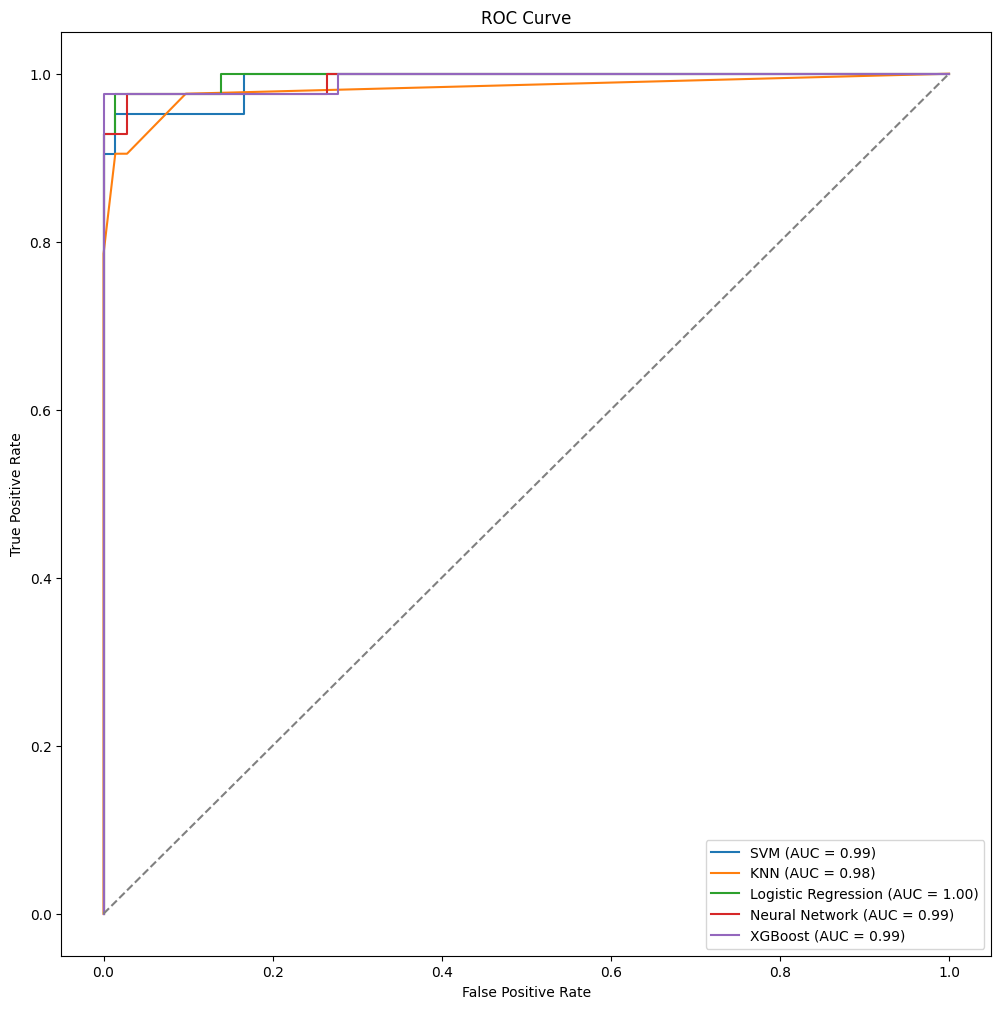


--- Evaluation Metrics ---
Model               Accuracy  Precision Recall    F1 Score  AUC       
SVM                 0.9649    1.0000    0.9048    0.9500    0.9914    
KNN                 0.9561    0.9744    0.9048    0.9383    0.9816    
Logistic Regression 0.9649    0.9750    0.9286    0.9512    0.9960    
Neural Network      0.9561    0.9512    0.9286    0.9398    0.9924    
XGBoost             0.9561    1.0000    0.8810    0.9367    0.9934    


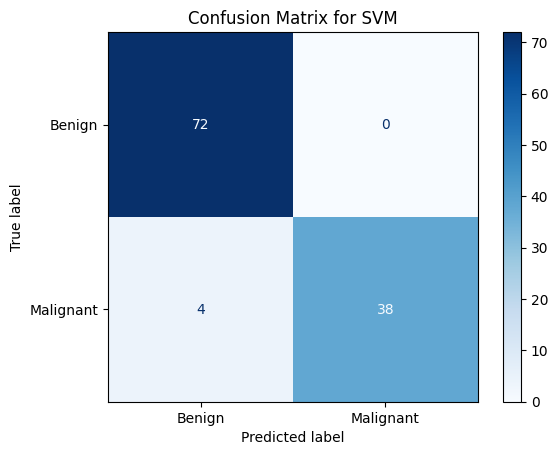

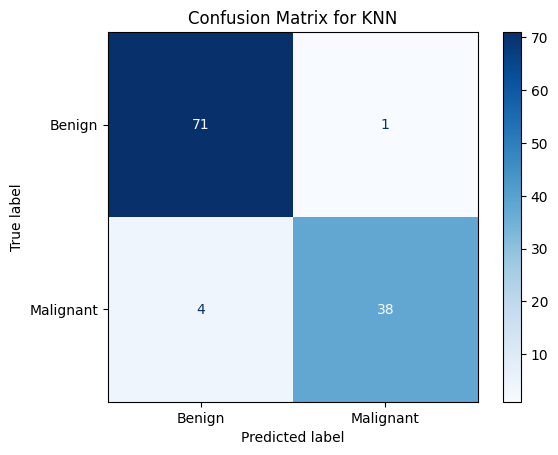

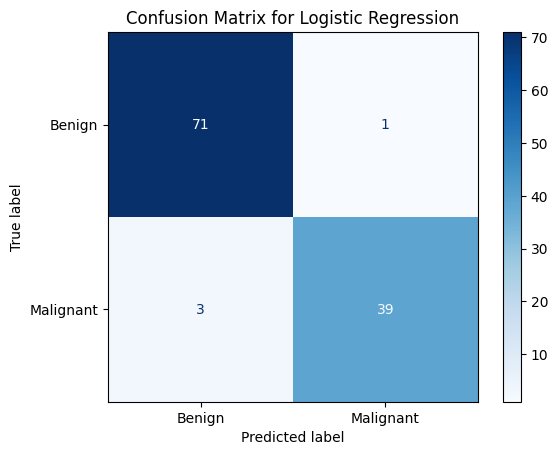

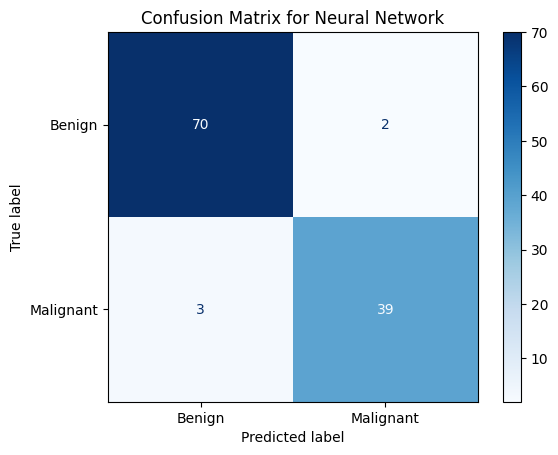

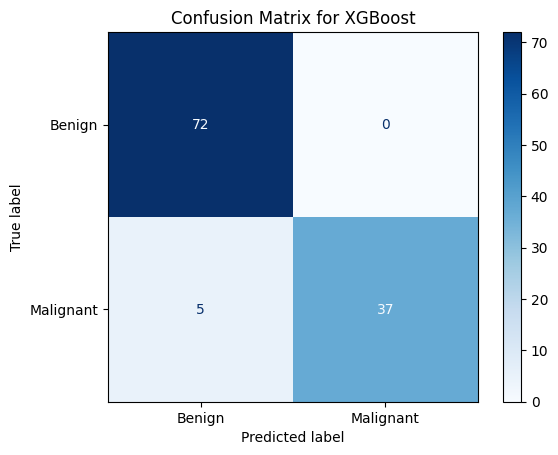

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay  # Corrected import
import seaborn as sns
import numpy as np

def evaluate_models(models, X_test, y_test):
    """
    Evaluate and plot performance metrics for the given models.

    Args:
    - models: Dictionary of trained models
    - X_test: Test features
    - y_test: Test labels
    """
    plt.figure(figsize=(12, 12))

    # Metrics dictionaries
    accuracies = {}
    precisions = {}
    recalls = {}
    f1_scores = {}
    auc_scores = {}

    for name, model in models.items():
        # Predict and get probabilities
        if name == 'Neural Network':
            pred = model.predict(X_test)
            pred_proba = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, 'predict_proba'):
            pred = model.predict(X_test)
            pred_proba = model.predict_proba(X_test)[:, 1]
        else:
            pred = model.predict(X_test)
            pred_proba = None

        # Calculate evaluation metrics
        accuracy = accuracy_score(y_test, pred)
        precision = precision_score(y_test, pred)
        recall = recall_score(y_test, pred)
        f1 = f1_score(y_test, pred)
        fpr, tpr, thresholds = roc_curve(y_test, pred_proba)
        roc_auc = auc(fpr, tpr)

        accuracies[name] = accuracy
        precisions[name] = precision
        recalls[name] = recall
        f1_scores[name] = f1
        auc_scores[name] = roc_auc

        # Plot ROC curve
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    # Plot the ROC curve
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()

    # Print metrics
    print("\n--- Evaluation Metrics ---")
    print(f"{'Model':<20}{'Accuracy':<10}{'Precision':<10}{'Recall':<10}{'F1 Score':<10}{'AUC':<10}")
    for name in models.keys():
        print(f"{name:<20}{accuracies[name]:<10.4f}{precisions[name]:<10.4f}{recalls[name]:<10.4f}{f1_scores[name]:<10.4f}{auc_scores[name]:<10.4f}")

    # Plot confusion matrix for each model
    for name, model in models.items():
        # Make predictions for the test set
        pred = model.predict(X_test)

        # Compute the confusion matrix
        cm = confusion_matrix(y_test, pred)

        # Create the confusion matrix display
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])

        # Plot the confusion matrix
        disp.plot(cmap='Blues')
        plt.title(f'Confusion Matrix for {name}')
        plt.show()


def main():
    # Load and preprocess data
    X, y = load_and_preprocess_data2()

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

    # Prepare models
    models = prepare_models(X_train, y_train)

    # Evaluate models
    evaluate_models(models, X_test, y_test)

if __name__ == "__main__":
    main()
